## PhD Results Analysis - A population genetic and strcutural biology-based approach for rare variant association analysis
This notebook records the analysis done for my PhD project.

In [ ]:
ls -lht

total 548M
-rw-r--r-- 1 root root 548M Aug  4 01:33 gnomad.v4.1.1.constraint_metrics.tsv.bgz
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data/


In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
plt.rcParams['font.family'] = 'Arial'

In [ ]:
g_coords = pd.read_csv("results_merged.csv")

In [ ]:
g_coords

,ensemblTrans_id,ensembleGene_id,uniprot_id,gene_name,ncbi_gene_id,genomic_coordinates,gene_lenght,gene_star,gene_end,domain_start,domain_end,pfam_domain,domain_range_nt,dom_gene_ratio,domain_annotations
0,ENSP00000379873,ENSG00000206503,P04439,HLA-A,3105,6:29944154-29944372,3339,29942532,29945870,218,290,PF07654,219,0.065588,Immunoglobulin C1-set
1,ENSP00000379873,ENSG00000206503,P04439,HLA-A,3105,6:29942626-29943533,3339,29942532,29945870,25,203,PF00129,908,0.271938,MHC class I-like antigen recognition-like
2,ENSP00000324806,ENSG00000082701,P49841,GSK3B,2932,3:120002162-119863456,273127,119821321,120094447,56,353,PF00069,138707,0.507848,Protein kinase domain
3,ENSP00000264883,ENSG00000138750,Q7Z3B4,NUP54,53371,4:76134341-76132572,33734,76114664,76148397,182,286,PF29949,1770,0.052469,"Nup54, alpha/beta domain"
4,ENSP00000264883,ENSG00000138750,Q7Z3B4,NUP54,53371,4:76117702-76115417,33734,76114664,76148397,453,491,PF18437,2286,0.067765,"Nup54, C-terminal interacting domain"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,ENSP00000381823,ENSG00000113615,O95486,SEC24A,10802,5:134686799-134698008,79125,134648785,134727909,501,739,PF04811,11210,0.141675,"Sec23/Sec24, trunk domain"
188,ENSP00000376472,ENSG00000134910,P46977,STT3A,3703,11:125613157-125614392,30240,125592852,125623091,512,580,PF22627,1236,0.040873,"AglB-like, core domain"
189,ENSP00000354932,ENSG00000174125,Q15399,TLR1,7096,4:38796923-38796486,8537,38796255,38804791,637,782,PF01582,438,0.051306,Toll/interleukin-1 receptor homology (TIR) domain
190,ENSP00000354932,ENSG00000174125,Q15399,TLR1,7096,4:38797172-38797101,8537,38796255,38804791,554,577,PF01463,72,0.008434,"Cysteine-rich flanking region, C-terminal"


In [ ]:
len(g_coords.pfam_domain.unique())

114

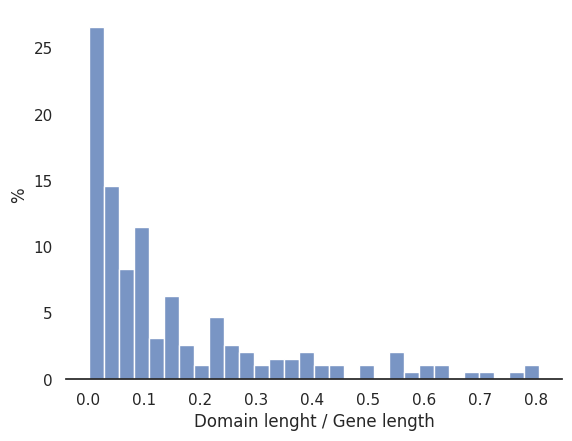

In [ ]:
sns.set(style="white")

sns.histplot(data=g_coords['dom_gene_ratio'], stat="percent", bins=30)

sns.despine(top=True, left=True)

plt.xlabel("Domain lenght / Gene length")
plt.ylabel("%")

plt.show()

In [ ]:
# gnomAD constraint metric v4.1

gnomad_metrics = pd.read_csv("/content/gnomad.v4.1.1.constraint_metrics.tsv.bgz",compression="gzip",sep="\t")

/tmp/ipykernel_589/3149533595.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gnomad_metrics = pd.read_csv("/content/gnomad.v4.1.1.constraint_metrics.tsv.bgz",compression="gzip",sep="\t")


In [ ]:
gnomad_metrics

,gene,gene_id,transcript,canonical,mane_select,transcript_version,transcript_type,transcript_level,chromosome,start_position,...,lof.gen_anc_obs.sas,lof.gen_anc_exp.global,lof.gen_anc_exp.afr,lof.gen_anc_exp.amr,lof.gen_anc_exp.eas,lof.gen_anc_exp.nfe,lof.gen_anc_exp.sas,lof.pLI,lof.pNull,lof.pRec
0,A1BG,1,NM_130786.4,True,True,NaN,NaN,NaN,NaN,NaN,...,"[0,0,0,0,0,1,1,2,4,5,5,5,6,7,9,11]","[0.0,0.0,0.20272597201164205,0.632765277292762...","[0.0,0.0,0.2261337178814478,0.6491257059175704...","[0.0,0.0,0.21784151141329394,0.613465794278608...","[0.0,0.0,0.193446334557225,0.5059996264236443,...","[0.0,0.0,0.1548984822019654,0.4217657270975451...","[0.0,0.0,0.21335448007398916,0.588837314428807...",6.735200e-15,0.617080,0.38292
1,A1BG,ENSG00000121410,ENST00000263100,True,True,ENST00000263100.8,protein_coding,2.0,chr19,58345183.0,...,"[0,0,0,0,0,1,1,2,4,5,5,5,6,7,9,11]","[0.0,0.0,0.20272597201164205,0.632765277292762...","[0.0,0.0,0.2261337178814478,0.6491257059175704...","[0.0,0.0,0.21784151141329394,0.613465794278608...","[0.0,0.0,0.193446334557225,0.5059996264236443,...","[0.0,0.0,0.1548984822019654,0.4217657270975451...","[0.0,0.0,0.21335448007398916,0.588837314428807...",6.735200e-15,0.617080,0.38292
2,A1BG,ENSG00000121410,ENST00000600966,False,False,ENST00000600966.1,protein_coding,1.0,chr19,58350594.0,...,"[0,0,0,0,0,1,1,1,2,3,3,3,3,4,6,7]","[0.0,0.0,0.12745807628155528,0.394051215668179...","[0.0,0.0,0.142676777789689,0.4035080328682651,...","[0.0,0.0,0.1374727483539508,0.3820528904552813...","[0.0,0.0,0.12211621472306991,0.315481251396050...","[0.0,0.0,0.09793915936360853,0.263526385216192...","[0.0,0.0,0.13451258313791928,0.366914966171532...",2.162000e-06,0.123820,0.87618
3,A1CF,29974,NM_001198818.2,False,False,NaN,NaN,NaN,NaN,NaN,...,"[0,0,0,0,0,0,1,1,1,2,3,3,4,6,6,11]","[0.0,0.0,0.4313305595052932,1.343064140033738,...","[0.0,0.0,0.5002647995129001,1.37158202983447,2...","[0.0,0.0,0.47761619978821573,1.299785656697409...","[0.0,0.0,0.42627052646010655,1.087817287942070...","[0.0,0.0,0.3437403092409679,0.910440236626728,...","[0.0,0.0,0.4668153923166099,1.2569123678558363...",1.147200e-11,0.007810,0.99219
4,A1CF,29974,NM_001198819.2,False,False,NaN,NaN,NaN,NaN,NaN,...,"[0,0,0,0,0,0,1,2,2,3,4,4,5,7,7,12]","[0.0,0.0,0.43234413417655776,1.346069067255858...","[0.0,0.0,0.5013253631777227,1.3746295840481613...","[0.0,0.0,0.47864067330743876,1.302661462393719...","[0.0,0.0,0.42719186084964933,1.090273645053266...","[0.0,0.0,0.34449339724328465,0.912424644437811...","[0.0,0.0,0.46780419223724734,1.259700690753409...",1.141500e-12,0.014229,0.98577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221893,NaN,ENSG00000289491,ENST00000688509,True,False,ENST00000688509.1,protein_coding,2.0,chr16,30610211.0,...,"[0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1]","[0.0,0.0,0.002939661126150364,0.00904070564903...","[0.0,0.0,0.003208348253720337,0.00926590330764...","[0.0,0.0,0.0031067022490740993,0.0087626864689...","[0.0,0.0,0.002755903075091865,0.00720812738711...","[0.0,0.0,0.0022071523632052393,0.0059928992018...","[0.0,0.0,0.0030384002047708202,0.0083928528474...",4.302900e-02,0.290520,0.66645
221894,NaN,ENSG00000289503,ENST00000553426,True,False,ENST00000553426.2,nonsense_mediated_decay,2.0,chr14,62075340.0,...,"[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...",NaN,NaN,NaN
221895,NaN,ENSG00000289517,ENST00000617178,True,False,ENST00000617178.5,nonsense_mediated_decay,2.0,chr22,42583836.0,...,"[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[nu

In [ ]:
# Selecting only MANE transcripts

gnomad_metrics = gnomad_metrics[gnomad_metrics['mane_select'] == True]

In [ ]:
gnomad_metrics

,gene,gene_id,transcript,canonical,mane_select,transcript_version,transcript_type,transcript_level,chromosome,start_position,...,lof.gen_anc_obs.sas,lof.gen_anc_exp.global,lof.gen_anc_exp.afr,lof.gen_anc_exp.amr,lof.gen_anc_exp.eas,lof.gen_anc_exp.nfe,lof.gen_anc_exp.sas,lof.pLI,lof.pNull,lof.pRec
0,A1BG,1,NM_130786.4,True,True,NaN,NaN,NaN,NaN,NaN,...,"[0,0,0,0,0,1,1,2,4,5,5,5,6,7,9,11]","[0.0,0.0,0.20272597201164205,0.632765277292762...","[0.0,0.0,0.2261337178814478,0.6491257059175704...","[0.0,0.0,0.21784151141329394,0.613465794278608...","[0.0,0.0,0.193446334557225,0.5059996264236443,...","[0.0,0.0,0.1548984822019654,0.4217657270975451...","[0.0,0.0,0.21335448007398916,0.588837314428807...",6.735200e-15,0.617080,0.38292
1,A1BG,ENSG00000121410,ENST00000263100,True,True,ENST00000263100.8,protein_coding,2.0,chr19,58345183.0,...,"[0,0,0,0,0,1,1,2,4,5,5,5,6,7,9,11]","[0.0,0.0,0.20272597201164205,0.632765277292762...","[0.0,0.0,0.2261337178814478,0.6491257059175704...","[0.0,0.0,0.21784151141329394,0.613465794278608...","[0.0,0.0,0.193446334557225,0.5059996264236443,...","[0.0,0.0,0.1548984822019654,0.4217657270975451...","[0.0,0.0,0.21335448007398916,0.588837314428807...",6.735200e-15,0.617080,0.38292
8,A1CF,29974,NM_014576.4,True,True,NaN,NaN,NaN,NaN,NaN,...,"[0,0,0,0,0,0,1,1,1,2,3,3,4,6,6,11]","[0.0,0.0,0.43133055950529325,1.343064140033738...","[0.0,0.0,0.5002647995129004,1.3715820298344696...","[0.0,0.0,0.4776161997882157,1.2997856566974093...","[0.0,0.0,0.42627052646010655,1.087817287942071...","[0.0,0.0,0.3437403092409679,0.910440236626728,...","[0.0,0.0,0.4668153923166102,1.256912367855837,...",1.147200e-11,0.007810,0.99219
18,A1CF,ENSG00000148584,ENST00000373997,True,True,ENST00000373997.8,protein_coding,2.0,chr10,50799409.0,...,"[0,0,0,0,0,0,1,1,1,2,3,3,4,6,6,11]","[0.0,0.0,0.4313305595052933,1.343064140033738,...","[0.0,0.0,0.5002647995129001,1.37158202983447,2...","[0.0,0.0,0.47761619978821573,1.299785656697409...","[0.0,0.0,0.42627052646010655,1.087817287942070...","[0.0,0.0,0.34374030924096793,0.910440236626728...","[0.0,0.0,0.4668153923166099,1.2569123678558363...",1.147200e-11,0.007810,0.99219
23,A2M,2,NM_000014.6,True,True,NaN,NaN,NaN,NaN,NaN,...,"[0,0,1,1,2,2,2,7,9,9,9,9,11,12,13,16]","[0.0,0.0,0.880693215301533,2.720057763767679,4...","[0.0,0.0,0.9881700430167781,2.7824808173056588...","[0.0,0.0,0.9506188359676011,2.6342629028739744...","[0.0,0.0,0.8457947474991481,2.1851057502922493...","[0.0,0.0,0.6797857687662179,1.8220683199520782...","[0.0,0.0,0.9292327023582113,2.534528785459128,...",2.377500e-29,0.000020,0.99998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221619,NaN,ENSG00000284024,ENST00000640019,True,True,ENST00000640019.3,protein_coding,2.0,chr10,14838306.0,...,"[0,0,0,0,2,2,2,2,2,2,3,3,4,4,4,5]","[0.0,0.0,0.25698300375161887,0.798067744354097...","[0.0,0.0,0.3045189898020039,0.8135790980884218...","[0.0,0.0,0.2898846213573187,0.7728958969301113...","[0.0,0.0,0.25888256237707774,0.648364322872581...","[0.0,0.0,0.2090507890787846,0.5458946236665285...","[0.0,0.0,0.2833369140198892,0.7488590989777034...",9.884400e-07,0.097306,0.90269
221672,NaN,ENSG00000285043,ENST00000338110,True,True,ENST00000338110.11,protein_coding,2.0,chr16,30053151.0,...,"[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...",NaN,NaN,NaN
221788,NaN,ENSG00000286135,ENST00000652090,True,True,ENST00000652090.1,protein_coding,2.0,chr10,122672850.0,...,"[0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]","[0.0,0.0,0.029579165283904883,0.09112142742474...","[0.0,0.0,0.032344926000161256,0.09343510490326...","[0.0,0.0,0.031323575266762015,0.08836929236967...","[0.0,0.0,0.02776952628478445,0.072568353883171...

In [ ]:
len(g_coords.ensembleGene_id.unique())

79

In [ ]:
# Using the gnomAD constraint data, select only genes from our domain coordinates dataset

gnomad_filtered = gnomad_metrics[gnomad_metrics['gene_id'].isin(g_coords.ensembleGene_id.unique())]

In [ ]:
gnomad_filtered

,gene,gene_id,transcript,canonical,mane_select,transcript_version,transcript_type,transcript_level,chromosome,start_position,...,lof.gen_anc_obs.sas,lof.gen_anc_exp.global,lof.gen_anc_exp.afr,lof.gen_anc_exp.amr,lof.gen_anc_exp.eas,lof.gen_anc_exp.nfe,lof.gen_anc_exp.sas,lof.pLI,lof.pNull,lof.pRec
6951,AKT1,ENSG00000142208,ENST00000649815,True,True,ENST00000649815.2,protein_coding,2.0,chr14,104769349.0,...,"[0,0,0,0,0,0,0,0,0,1,1,1,2,2,2,2]","[0.0,0.0,0.3138194750358465,0.968835375079232,...","[0.0,0.0,0.35341716166094983,0.991226202432711...","[0.0,0.0,0.3400789770925151,0.9390823328143404...","[0.0,0.0,0.30233025441076167,0.777237484800315...","[0.0,0.0,0.24277273479620504,0.649752123626844...","[0.0,0.0,0.33261736905183564,0.902920746736809...",9.937900e-01,2.189000e-08,6.206400e-03
20123,BECN1,ENSG00000126581,ENST00000590099,True,True,ENST00000590099.6,protein_coding,2.0,chr17,42810134.0,...,"[0,0,0,1,2,2,2,2,2,2,2,2,2,2,2,3]","[0.0,0.0,0.29720151834330844,0.917435042469718...","[0.0,0.0,0.33456325990110747,0.938438360828020...","[0.0,0.0,0.3218330308248104,0.8889241098573304...","[0.0,0.0,0.2862386625662822,0.7366438143889045...","[0.0,0.0,0.22997901885334113,0.615295401477142...","[0.0,0.0,0.3146795964283655,0.8550845383098422...",9.999800e-01,1.899500e-11,1.790100e-05
37624,CHUK,ENSG00000213341,ENST00000370397,True,True,ENST00000370397.8,protein_coding,2.0,chr10,100188300.0,...,"[0,0,0,0,0,0,0,0,1,2,2,2,2,3,3,5]","[0.0,0.0,0.4787544790225102,1.4765220904785092...","[0.0,0.0,0.5336729589013836,1.510632076007726,...","[0.0,0.0,0.5139805277410272,1.4296644156789684...","[0.0,0.0,0.4572163322591379,1.185217701986469,...","[0.0,0.0,0.3674171963351562,0.9868710090525908...","[0.0,0.0,0.5023065872549993,1.3747934860038797...",9.998400e-01,3.591300e-13,1.646200e-04
43475,CREBBP,ENSG00000005339,ENST00000262367,True,True,ENST00000262367.10,protein_coding,2.0,chr16,3725054.0,...,"[0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1]","[0.0,0.0,1.4222053150055047,4.409819505754092,...","[0.0,0.0,1.6188373672216163,4.511916040642892,...","[0.0,0.0,1.5544806812650882,4.275475321185613,...","[0.0,0.0,1.3824653026553122,3.5424410697141377...","[0.0,0.0,1.110251700471189,2.9670996918374493,...","[0.0,0.0,1.5211196635307638,4.114732586114104,...",1.000000e+00,2.730500e-79,9.381200e-48
49164,DDOST,ENSG00000244038,ENST00000602624,True,True,ENST00000602624.7,protein_coding,2.0,chr1,20651777.0,...,"[0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,4]","[0.0,0.0,0.21668962415857762,0.671552786655668...","[0.0,0.0,0.24197938288006848,0.687774536560426...","[0.0,0.0,0.2330271602253353,0.6506330779122632...","[0.0,0.0,0.20714611125752486,0.538284736181945...","[0.0,0.0,0.16622601171730625,0.448601159637419...","[0.0,0.0,0.22794450979613606,0.625243276354660...",5.056900e-04,1.367700e-03,9.981300e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202791,TYK2,ENSG00000105397,ENST00000525621,True,True,ENST00000525621.6,protein_coding,2.0,chr19,10350533.0,...,"[0,0,0,0,0,0,0,1,1,2,2,2,2,2,2,5]","[0.0,0.0,0.6198231375359748,1.9282738872027236...","[0.0,0.0,0.6967365914039033,1.9756783685655737...","[0.0,0.0,0.6702690695836313,1.8691284260618934...","[0.0,0.0,0.5957012448843473,1.5454423541109388...","[0.0,0.0,0.4777312867721726,1.2901758152175655...","[0.0,0.0,0.6560934460166536,1.796374893818581,...",2.784100e-07,3.531500e-08,1.000000e+00
206518,UVRAG,ENSG00000198382,ENST00000356136,True,True,ENST00000356136.8,protein_coding,2.0,chr11,75815210.0,...,"[0,0,0,0,0,0,0,0,1,1,1,1,1,3,3,3]","[0.0,0.0,0.3893681887055696,1.2050298609562138...","[0.0,0.0,0.4395911603434853,1.2323798617357336...","[0.0,0.0,0.42224383596982407,1.166820130775030...","[0.0,0.0,0.37592026011202084,0.969584125954962...","[0.0,0.0,0.3023229243380362,0.8089204970902623...","[0.0,0.0,0.4127436449502707,1.123748451953554,...",1.000000e+00,7.020300e-15,3.182100e-07
207472,VPS18,ENSG00000104142,ENST00000220509,True,True,ENST00000220509.10,protein_coding,2.0,chr15,40894450.0,...,"[0,0,

Text(0, 0.5, '%')

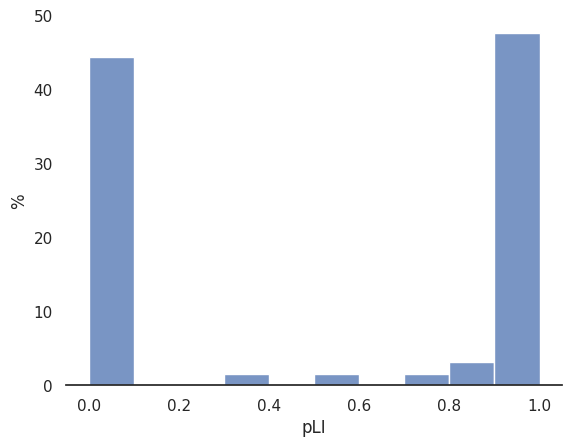

In [ ]:
# Plotting pLI scores distribution in our dataset

sns.set(style="white")

sns.histplot(data=gnomad_filtered["lof.pLI"], stat="percent", bins=10)

sns.despine(top=True, left=True)
plt.xlabel("pLI")
plt.ylabel("%")

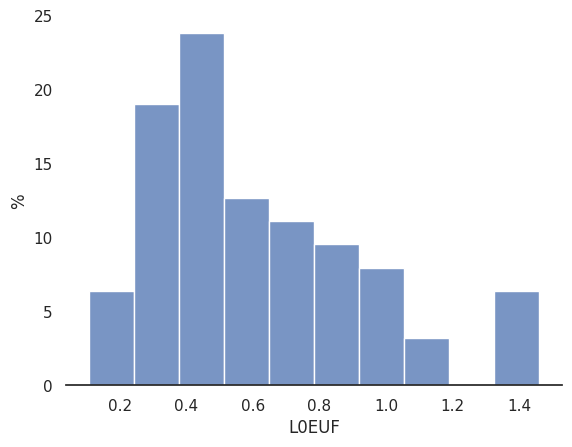

In [ ]:
# Plotting LOFEUF scores distribution in our dataset


sns.histplot(data=gnomad_filtered["lof.oe_ci.upper"],  stat="percent", bins=10)

sns.despine(top=True, left=True)
plt.xlabel("L0EUF")
plt.ylabel("%")



plt.show()

In [ ]:
len(gnomad_filtered[gnomad_filtered["lof.oe_ci.upper"] < 1]) / len(gnomad_filtered["lof.oe_ci.upper"])

0.8088235294117647

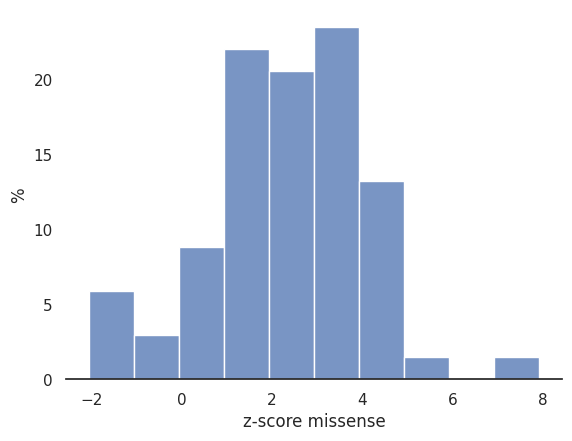

In [ ]:
# Plotting missense Z scores distribution in our dataset

sns.histplot(data=gnomad_filtered["mis.z_score"], stat="percent", bins=10)

sns.despine(top=True, left=True)
plt.xlabel("z-score missense")
plt.ylabel("%")



plt.show()

In [ ]:
len(gnomad_filtered[gnomad_filtered["mis.z_score"] > 0]) / len(gnomad_filtered["mis.z_score"])

0.9117647058823529

Next, I checked the intersection between our genes and GWAS Catalog data for Alzheimer Disease and genebass.

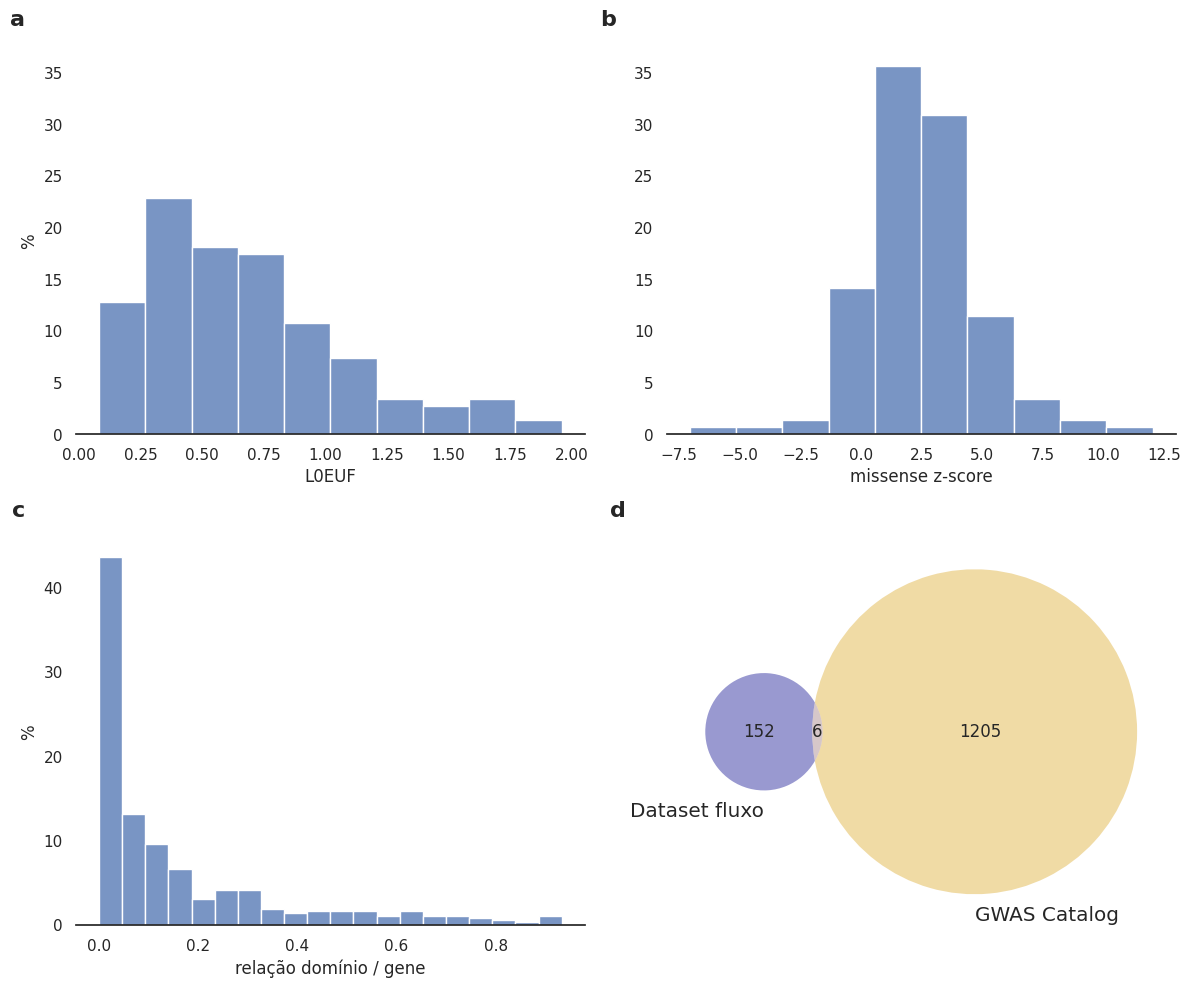

In [ ]:
# Strcturing all four plots in one figura
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# LOEUF
sns.histplot(data=gnomad_filtered["lof.oe_ci.upper"], stat="percent", bins=10, ax=axes[0, 0])
axes[0, 0].set_xlabel("L0EUF")
axes[0, 0].set_ylabel("%")

# Missense Z-score
sns.histplot(data=gnomad_filtered["mis.z_score"], stat="percent", bins=10, ax=axes[0, 1])
axes[0, 1].set_xlabel("missense z-score")
axes[0, 1].set_ylabel(None)

# Normalizing y axes in the upper side
y_max_1 = axes[0, 0].get_ylim()[1]
y_max_2 = axes[0, 1].get_ylim()[1]
global_max = max(y_max_1, y_max_2)

axes[0, 0].set_ylim(0, global_max)
axes[0, 1].set_ylim(0, global_max)

# Domain-gene ratio
sns.histplot(data=g_coords['dom_gene_ratio'], stat="percent", bins=20, ax=axes[1, 0])
sns.despine(top=True, left=True)
axes[1, 0].set_xlabel("relação domínio / gene")
axes[1, 0].set_ylabel("%")

# Venn Diagram
venn2([set1, set2], set_labels=('Dataset fluxo', 'GWAS Catalog'),
      set_colors=('darkblue', 'goldenrod'), ax=axes[1, 1])

labels = ['a', 'b', 'c', 'd']

for i, ax in enumerate(axes.flat):
    ax.text(-0.1, 1.1, labels[i], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save or show the plot
plt.savefig('combined_plots.png')
plt.show()

In [ ]:
gnomad_to_integrate = gnomad_filtered[["gene_id","lof.oe_ci.upper", "mis.z_score", "lof.pLI"]]

In [ ]:
integration_df = g_coords.merge(gnomad_to_integrate, left_on="ensembleGene_id", right_on="gene_id", how="left")

In [ ]:
integration_df.to_csv("gcoords_int_gnomad_constraint.csv")

## CCRs integration

In [ ]:
# Loading CCR data for hg38 (reference here)

ccrs_hg38 = pd.read_csv("/content/sort_weightedresiduals-cpg-synonymous-novariant.txt", sep="\t")

/tmp/ipykernel_152/2601872335.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ccrs_hg38 = pd.read_csv("/content/sort_weightedresiduals-cpg-synonymous-novariant.txt", sep="\t")


In [ ]:
ccrs_hg38

,chrom,start,end,gene,transcript,exon,ranges,varflag,syn_density,cpg,cov_score,resid,resid_pctile,weighted_pct
0,1,924431,924948,SAMD11,ENST00000342066,2/14,"924431-924948,925921-925943","VARFALSE,VARFALSE",0.000,0.17,535.89,45.893,17.671675,99.866308
1,1,925921,925943,SAMD11,ENST00000342066,2/14,"924431-924948,925921-925943","VARFALSE,VARFALSE",0.000,0.17,535.89,45.893,17.671675,99.866308
2,1,925943,925944,SAMD11,ENST00000342066,2/14,925943-925944,VARTRUE,0.000,0.00,0.00,-0.898,0.000000,0.000000
3,1,925944,925947,SAMD11,ENST00000342066,2/14,925944-925947,VARFALSE,0.333,0.00,3.00,-0.497,0.151354,7.409241
4,1,925947,925948,SAMD11,ENST00000342066,2/14,925947-925948,VARTRUE,0.000,0.00,0.00,-0.898,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6937437,X,155669771,155669772,TMLHE,ENST00000675642,2/9,155669771-155669772,VARTRUE,0.000,0.00,0.00,-0.909,0.000000,0.000000
6937438,X,155669772,155669774,TMLHE,ENST00000675642,2/9,155669772-155669774,VARFALSE,0.000,0.00,1.90,-0.666,1.001567,0.656806
6937439,X,155669774,155669779,TMLHE,ENST00000675642,2/9,155669774-155669779,VARTRUE,0.000,0.00,0.00,-0.909,0.000000,0.000000
6937440,X,155669779,155669788,TMLHE,ENST00000675642,2/9,155669779-155669788,VARFALSE,0.000,0.00,8.55,-0.344,2.334152,11.831071


In [ ]:
# Generating

# Extracting coordinates from g_coords
coords = g_coords['genomic_coordinates'].str.split(':', expand=True)[1].str.split('-', expand=True).astype(int)
g_coords['d_start_raw'] = coords[0]
g_coords['d_end_raw'] = coords[1]

# Sorting domain coordinates
g_coords['d_start'] = np.minimum(g_coords['d_start_raw'], g_coords['d_end_raw'])
g_coords['d_end'] = np.maximum(g_coords['d_start_raw'], g_coords['d_end_raw'])

# Same for CCRs
ccrs_hg38['start'] = ccrs_hg38['start'].astype(int)
ccrs_hg38['end'] = ccrs_hg38['end'].astype(int)
ccrs_hg38['c_start'] = np.minimum(ccrs_hg38['start'], ccrs_hg38['end'])
ccrs_hg38['c_end'] = np.maximum(ccrs_hg38['start'], ccrs_hg38['end'])

# Merging domain coordinates and CCRs coordinates datasets
merged = pd.merge(
    g_coords[['gene_name', 'd_start', 'd_end', "uniprot_id", "domain_annotations"]],
    ccrs_hg38[['chrom','gene', 'c_start', 'c_end', "weighted_pct", "ranges", "varflag"]],
    left_on='gene_name', # Validation question: are these the best keys for merging?
    right_on='gene',
    how='inner'
)

# Fiding the strat of (possible) intersection
intersection_start = np.maximum(merged['d_start'], merged['c_start'])

# Fiding the end
intersection_end = np.minimum(merged['d_end'], merged['c_end'])

# Calculating the size of intersection (clip is used for situation where there is no overlap)
merged['overlap_amount'] = (intersection_end - intersection_start).clip(lower=0)

# Checking for total intersection
subset_mask = (merged['c_start'] <= merged['d_start']) & (merged['d_end'] <= merged['c_end'])

# Checking for overlap
overlap_mask = np.maximum(merged['d_start'], merged['c_start']) < np.minimum(merged['d_end'], merged['c_end'])

# Assigning status
merged['status'] = np.nan
merged.loc[overlap_mask, 'status'] = 'Overlap'     # Set overlaps first
merged.loc[subset_mask, 'status'] = 'Totally found' # Overwrite subsets (higher priority)

# Filtering for only relevant results
results = merged.dropna(subset=['status'])

print(results[['gene_name', 'd_start', 'd_end', 'c_start', 'c_end', 'status']].head())

    gene_name   d_start     d_end   c_start     c_end   status
194   ATP5F1A  46089901  46091786  46089890  46089913  Overlap
195   ATP5F1A  46089901  46091786  46089913  46089914  Overlap
196   ATP5F1A  46089901  46091786  46089914  46089916  Overlap
197   ATP5F1A  46089901  46091786  46089916  46089917  Overlap
198   ATP5F1A  46089901  46091786  46089917  46089920  Overlap


/tmp/ipykernel_152/2525256971.py:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Overlap' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  merged.loc[overlap_mask, 'status'] = 'Overlap'     # Set overlaps first


In [ ]:
results

,gene_name,d_start,d_end,uniprot_id,domain_annotations,chrom,gene,c_start,c_end,weighted_pct,ranges,varflag,overlap_amount,status
194,ATP5F1A,46089901,46091786,P25705,"ATPase, F1/V1/A1 complex, alpha/beta subunit, ...",18,ATP5F1A,46089890,46089913,71.950923,46089890-46089913,VARFALSE,12,Overlap
195,ATP5F1A,46089901,46091786,P25705,"ATPase, F1/V1/A1 complex, alpha/beta subunit, ...",18,ATP5F1A,46089913,46089914,0.000000,46089913-46089914,VARTRUE,1,Overlap
196,ATP5F1A,46089901,46091786,P25705,"ATPase, F1/V1/A1 complex, alpha/beta subunit, ...",18,ATP5F1A,46089914,46089916,4.599400,46089914-46089916,VARFALSE,2,Overlap
197,ATP5F1A,46089901,46091786,P25705,"ATPase, F1/V1/A1 complex, alpha/beta subunit, ...",18,ATP5F1A,46089916,46089917,0.000000,46089916-46089917,VARTRUE,1,Overlap
198,ATP5F1A,46089901,46091786,P25705,"ATPase, F1/V1/A1 complex, alpha/beta subunit, ...",18,ATP5F1A,46089917,46089920,7.409241,46089917-46089920,VARFALSE,3,Overlap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240195,UQCRC2,21965488,21980556,P22695,"Peptidase M16, C-terminal",16,UQCRC2,21976214,21976215,0.000000,21976214-21976215,VARTRUE,1,Overlap
240196,UQCRC2,21965488,21980556,P22695,"Peptidase M16, C-terminal",16,UQCRC2,21976215,21976230,52.693172,21976215-21976230,VARFALSE,15,Overlap
240197,UQCRC2,21965488,21980556,P22695,"Peptidase M16, C-terminal",16,UQCRC2,21976230,21976231,0.000000,21976230-21976231,VARTRUE,1,Overlap
240198,UQCRC2,21965488,21980556,P22695,"Peptidase M16, C-terminal",16,UQCRC2,21976231,21976243,83.174928,"21976231-21976243,21980546-21980566","VARFALSE,VARFALSE",12,Overlap


In [ ]:
print(len(results[results["weighted_pct"] >= 95].groupby("gene_name").count()))

print(len(results[results["weighted_pct"] >= 90].groupby("gene_name").count()))

print(len(results[results["weighted_pct"] >= 80].groupby("gene_name").count()))

68
103
120


In [ ]:
results.sort_values(by="overlap_amount").tail(50)

,gene_name,d_start,d_end,uniprot_id,domain_annotations,chrom,gene,c_start,c_end,weighted_pct,ranges,varflag,overlap_amount,status
138065,MAP3K5,136601848,136622945,Q99683,Protein kinase domain,6,MAP3K5,136613160,136613231,96.165243,136613160-136613231,VARFALSE,71,Overlap
236283,TUBB2B,3225456,3227537,Q9BVA1,"Tubulin/FtsZ, GTPase domain",6,TUBB2B,3226197,3226269,97.606357,"3226197-3226269,3226560-3226583","VARFALSE,VARFALSE",72,Overlap
237631,TUBB4B,137242999,137243364,P68371,"Tubulin/FtsZ, 2-layer sandwich domain",9,TUBB4B,137243062,137243134,96.255041,137243062-137243134,VARFALSE,72,Overlap
203809,PIK3CB,138755803,138759220,P42338,"Phosphatidylinositol 3-kinase, adaptor-binding...",3,PIK3CB,138755876,138755948,96.305035,138755876-138755948,VARFALSE,72,Overlap
55520,EIF2AK2,37107327,37126395,P19525,Protein kinase domain,2,EIF2AK2,37119977,37120049,96.305035,37119977-37120049,VARFALSE,72,Overlap
195790,PIK3R1,68293475,68295471,P27986,"PI3K regulatory subunit p85-related , inter-SH...",5,PIK3R1,68294560,68294632,96.259197,68294560-68294632,VARFALSE,72,Overlap
195011,RAF1,12584586,12591787,P04049,Protein kinase domain,3,RAF1,12585694,12585766,96.267661,12585694-12585766,VARFALSE,72,Overlap
161959,PSMD4,151254798,151264891,Q5VWC4,"von Willebrand factor, type A",1,PSMD4,151262160,151262234,96.916838,"151254801-151254808,151262160-151262234","VARFALSE,VARFALSE",74,Overlap
198026,PSMC2,103355762,103362725,P35998,"26S proteasome regulatory subunit 7-like, OB d...",7,PSMC2,103361974,103362049,96.550227,103361974-103362049,VARFALSE,75,Overlap
198239,PPP3R1,68181008,68187270,P63098,EF-hand domain,2,PPP3R1,68186568,68186643,96.550227,68186568-68186643,VARFALSE,75,Overlap


<Axes: ylabel='Frequency'>

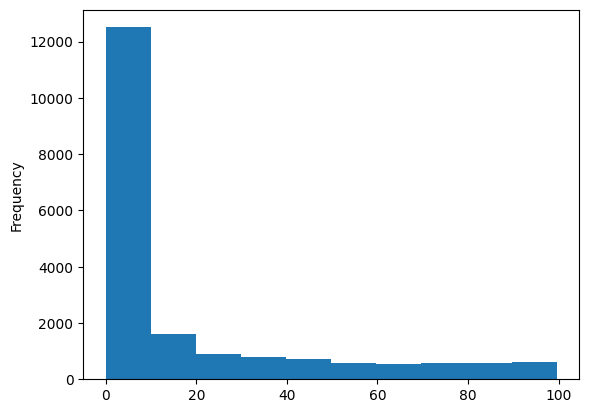

In [ ]:
results.weighted_pct.plot(kind="hist")

In [ ]:
results[results["gene_name"].isin({"APP"}) & (results["weighted_pct"] > 80)]

,gene_name,d_start,d_end,uniprot_id,domain_annotations,chrom,gene,c_start,c_end,weighted_pct,ranges,varflag,overlap_amount,status
1338,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25955685,25955715,81.128951,25955685-25955715,VARFALSE,30,Overlap
1378,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25975131,25975184,93.639392,25975131-25975184,VARFALSE,53,Overlap
1382,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25975203,25975228,84.629858,"25975203-25975228,25975953-25975961","VARFALSE,VARFALSE",25,Overlap
1383,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25975953,25975961,84.629858,"25975203-25975228,25975953-25975961","VARFALSE,VARFALSE",8,Overlap
1395,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25976006,25976028,81.511063,"25976006-25976028,25982343-25982351","VARFALSE,VARFALSE",22,Overlap
1396,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25982343,25982351,81.511063,"25976006-25976028,25982343-25982351","VARFALSE,VARFALSE",8,Overlap
1941,APP,26000025,26000180,P05067,Pancreatic trypsin inhibitor Kunitz domain,21,APP,26000162,26000182,87.583348,"26000162-26000182,26021839-26021857","VARFALSE,VARFALSE",18,Overlap


## Plotting domain-CCRs overlaps

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch

def plot_gene_structure(exons, filename='gene_structure_with_introns.png'):
    """
    Generates a graphic representation of a gene with exons connected by intron lines.
    """
    # 1. Sort exons
    exons.sort(key=lambda x: x[0])

    # 2. Setup Dimensions
    widths = [float(e[1] - e[0]) for e in exons]

    # 3. Create Figure and GridSpec
    # wspace=0.3 adds a gap between subplots, which acts as the visual "length" of the intron
    fig = plt.figure(figsize=(12, 1))
    gs = gridspec.GridSpec(1, len(exons), width_ratios=widths, wspace=0.15)

    axes = []

    # 4. Plot Exons and Internal Lines
    for i, (start, end) in enumerate(exons):
        ax = fig.add_subplot(gs[i])
        axes.append(ax)

        ax.set_xlim(start, end)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])

        # Turn off borders
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Draw the "Backbone" line INSIDE the exon subplot
        # This ensures the line runs through the exon itself
        ax.plot([start, end], [0.5, 0.5], color='black', linewidth=1, zorder=1)

        # Draw the Exon Rectangle
        ax.axhspan(ymin=0.3, ymax=0.7, xmin=0, xmax=1,
                   facecolor='lightgray', edgecolor='black', alpha=1, zorder=2)

    # 5. Draw Intron Lines (Connecting the subplots)
    # We loop through the axes and connect ax[i] to ax[i+1]
    for i in range(len(axes) - 1):
        ax_left = axes[i]
        ax_right = axes[i+1]

        # Create a line from the right edge (1, 0.5) of the left subplot
        # to the left edge (0, 0.5) of the right subplot.
        con = ConnectionPatch(xyA=(1, 0.5), coordsA=ax_left.transAxes,
                              xyB=(0, 0.5), coordsB=ax_right.transAxes,
                              color='gray', linewidth=1)

        # Add the line to the plot
        fig.add_artist(con)

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close()

if __name__ == "__main__":
    dummy_exons = [(58597456,58597518),
(58597546,58597641),
(58599597,58599724),
(58610296,58610517),
(58610998,58611107),
(58611807,58611991),
(58621470,58621621),
(58627699,58627883),
(58633195,58633359),
(58640776,58640960),
(58643885,58643978),
(58646054,58646204),
(58665096,58665197),
(58676276,58676293),
(58679123,58679282),
(58682195,58682314),
(58717576,58717727),
(58748911,58749036),
(58749479,58749534)]
    plot_gene_structure(dummy_exons)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
results[results["gene_name"].isin({"APP"}) & (results["weighted_pct"] > 80)]

,gene_name,d_start,d_end,uniprot_id,domain_annotations,chrom,gene,c_start,c_end,weighted_pct,ranges,varflag,overlap_amount,status
1338,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25955685,25955715,81.128951,25955685-25955715,VARFALSE,30,Overlap
1378,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25975131,25975184,93.639392,25975131-25975184,VARFALSE,53,Overlap
1382,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25975203,25975228,84.629858,"25975203-25975228,25975953-25975961","VARFALSE,VARFALSE",25,Overlap
1383,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25975953,25975961,84.629858,"25975203-25975228,25975953-25975961","VARFALSE,VARFALSE",8,Overlap
1395,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25976006,25976028,81.511063,"25976006-25976028,25982343-25982351","VARFALSE,VARFALSE",22,Overlap
1396,APP,25954633,25982469,P05067,"Amyloidogenic glycoprotein, E2 domain",21,APP,25982343,25982351,81.511063,"25976006-25976028,25982343-25982351","VARFALSE,VARFALSE",8,Overlap
1941,APP,26000025,26000180,P05067,Pancreatic trypsin inhibitor Kunitz domain,21,APP,26000162,26000182,87.583348,"26000162-26000182,26021839-26021857","VARFALSE,VARFALSE",18,Overlap


In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch, Patch

def plot_gene_structure(exons, domain=None, constraints=None, filename='gene_with_constraints_scored.png'):
    """
    Generates a graphic representation of a gene with exons, introns,
    a domain marker below, and color-coded constraint regions above based on score.

    Args:
        exons (list): List of (start, end) tuples.
        domain (tuple): (start, end) tuple for the domain to highlight.
        constraints (list): List of (start, end, score) tuples.
                            Score > 90 -> Red, Score > 80 -> Orange.
        filename (str): Output filename.
    """
    # 1. Sort and Setup
    exons.sort(key=lambda x: x[0])
    widths = [float(e[1] - e[0]) for e in exons]

    if constraints is None:
        constraints = []

    # 2. Figure Setup
    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(1, len(exons), width_ratios=widths, wspace=0.15)
    axes = []

    # Constants for layout
    EXON_Y_MIN, EXON_Y_MAX = 0.4, 0.8
    DOMAIN_Y = 0.2
    CONSTRAINT_Y = 0.9
    TICK_HEIGHT = 0.1

    # 3. Draw Exons, Domain, and Constraints
    for i, (start, end) in enumerate(exons):
        ax = fig.add_subplot(gs[i])
        axes.append(ax)

        ax.set_xlim(start, end)
        ax.set_ylim(0, 1.1)
        ax.axis('off')

        # --- A. Draw Intron/Backbone Line ---
        ax.plot([start, end], [(EXON_Y_MIN + EXON_Y_MAX)/2] * 2,
                color='black', linewidth=1, zorder=1)

        # --- B. Draw Exon Rectangle ---
        ax.axhspan(ymin=EXON_Y_MIN, ymax=EXON_Y_MAX, xmin=0, xmax=1,
                   facecolor='lightgray', edgecolor='black', zorder=2)

        # --- C. Draw Domain (Bottom / Black) ---
        if domain:
            d_start, d_end = domain
            overlap_start = max(start, d_start)
            overlap_end = min(end, d_end)

            if overlap_start < overlap_end:
                ax.plot([overlap_start, overlap_end], [DOMAIN_Y, DOMAIN_Y],
                        color='black', linestyle='--', linewidth=1.5, zorder=3)

                if start <= d_start <= end:
                    ax.plot([d_start, d_start], [DOMAIN_Y - TICK_HEIGHT/2, DOMAIN_Y + TICK_HEIGHT/2],
                            color='black', linewidth=2, zorder=3)
                if start <= d_end <= end:
                    ax.plot([d_end, d_end], [DOMAIN_Y - TICK_HEIGHT/2, DOMAIN_Y + TICK_HEIGHT/2],
                            color='black', linewidth=2, zorder=3)

        # --- D. Draw Constraints (Top / Colored by Score) ---
        for c_start, c_end, score in constraints:
            # Determine Color
            if score > 90:
                c_color = 'red'
            elif score > 80:
                c_color = 'orange'
            else:
                c_color = 'gray' # Fallback for scores <= 80

            overlap_start = max(start, c_start)
            overlap_end = min(end, c_end)

            if overlap_start < overlap_end:
                # Segment
                ax.plot([overlap_start, overlap_end], [CONSTRAINT_Y, CONSTRAINT_Y],
                        color=c_color, linestyle='--', linewidth=1.5, zorder=3)

                # Ticks
                if start <= c_start <= end:
                    ax.plot([c_start, c_start], [CONSTRAINT_Y - TICK_HEIGHT/2, CONSTRAINT_Y + TICK_HEIGHT/2],
                            color=c_color, linewidth=2, zorder=3)
                if start <= c_end <= end:
                    ax.plot([c_end, c_end], [CONSTRAINT_Y - TICK_HEIGHT/2, CONSTRAINT_Y + TICK_HEIGHT/2],
                            color=c_color, linewidth=2, zorder=3)

    # 4. Draw Connections
    for i in range(len(axes) - 1):
        ax_left = axes[i]
        ax_right = axes[i+1]

        current_exon_end = exons[i][1]
        next_exon_start = exons[i+1][0]

        # --- A. Connect Exons ---
        con = ConnectionPatch(xyA=(1, (EXON_Y_MIN + EXON_Y_MAX)/2), coordsA=ax_left.transAxes,
                              xyB=(0, (EXON_Y_MIN + EXON_Y_MAX)/2), coordsB=ax_right.transAxes,
                              color='black', linewidth=1)
        fig.add_artist(con)

        # --- B. Connect Domain ---
        if domain:
            d_start, d_end = domain
            if d_start < next_exon_start and d_end > current_exon_end:
                con_domain = ConnectionPatch(
                    xyA=(1, DOMAIN_Y), coordsA=ax_left.transAxes,
                    xyB=(0, DOMAIN_Y), coordsB=ax_right.transAxes,
                    color='black', linestyle='--', linewidth=1.5
                )
                fig.add_artist(con_domain)

        # --- C. Connect Constraints ---
        for c_start, c_end, score in constraints:
            # Determine Color again for connection
            if score >= 90:
                c_color = 'red'
            elif score >= 80:
                c_color = 'orange'
            else:
                c_color = 'gray'

            if c_start < next_exon_start and c_end > current_exon_end:
                con_constraint = ConnectionPatch(
                    xyA=(1, CONSTRAINT_Y), coordsA=ax_left.transAxes,
                    xyB=(0, CONSTRAINT_Y), coordsB=ax_right.transAxes,
                    color=c_color, linestyle='--', linewidth=1.5
                )
                fig.add_artist(con_constraint)

    # 5. Create Legend
    legend_elements = [
        Patch(facecolor='red', edgecolor='red', label=r"$CCR \geq 90º percentil$"),
        Patch(facecolor='orange', edgecolor='orange', label="$CCR \geq 80º percentil$")
    ]

    # Place legend in lower left relative to the whole figure
    fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.9, 0.01),
               title=None, frameon=True)

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close()

# --- Example Usage ---
if __name__ == "__main__":
    # Exons definition
    my_exons = [
        (26170564,26170620), (26111979,26112146),
        (26089943,26090072), (26053236,26053348), (26051000,26051193),
        (26021840,26022042), (26000015,26000182), (25997360,25997416),
        (25982344,25982477), (25975954,25976028), (25975070,25975228),
        (25955627,25955755), (25954590,25954689), (25911741,25911962),
        (25905024,25905077), (25897573,25897673), (25891722,25891868),
        (25881673,25881771)
    ]

    # Domain definition
    my_domain = (25954633, 25982469)

    # Constraint definition (start, end, score)
    my_constraints = [
        (25955685,25955715, 81.128951), # Should be Orange
        (25975131,25975184, 93.639392),
        (25975203,25975228, 84.629858)# Should be Red
    ]

    plot_gene_structure(my_exons, domain=my_domain, constraints=my_constraints, filename="gene_constraints_scored.png")

<>:143: SyntaxWarning: invalid escape sequence '\g'
<>:143: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipython-input-2036079985.py:143: SyntaxWarning: invalid escape sequence '\g'
  Patch(facecolor='orange', edgecolor='orange', label="$CCR \geq 80º percentil$")


In [ ]:
# PLotting APP

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch, Patch, Rectangle

def plot_gene_structure(exons, domain=None, constraints=None, filename='gene_with_constraints_scored.png'):
    """
    Generates a graphic representation of a gene.
    - Exons are lightgray by default.
    - Specific sub-regions of exons overlapping with constraints are colored Orange/Red.
    - Constraint markers are also shown above the gene.

    Args:
        exons (list): List of (start, end) tuples.
        domain (tuple): (start, end) tuple for the domain to highlight.
        constraints (list): List of (start, end, score) tuples.
    """
    # 1. Sort and Setup
    exons.sort(key=lambda x: x[0])
    widths = [float(e[1] - e[0]) for e in exons]

    if constraints is None:
        constraints = []

    # Sort constraints by score (ascending) so Red (high score) draws ON TOP of Orange (low score)
    # if they overlap.
    constraints.sort(key=lambda x: x[2])

    # 2. Figure Setup
    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(1, len(exons), width_ratios=widths, wspace=0.15)
    axes = []

    # Constants for layout
    EXON_Y_MIN, EXON_Y_MAX = 0.4, 0.8
    DOMAIN_Y = 0.2
    CONSTRAINT_Y = 0.9
    TICK_HEIGHT = 0.1

    # 3. Draw Exons, Domain, and Constraints
    for i, (start, end) in enumerate(exons):
        ax = fig.add_subplot(gs[i])
        axes.append(ax)

        ax.set_xlim(start, end)
        ax.set_ylim(0, 1.1)
        ax.axis('off')

        # --- A. Draw Intron/Backbone Line ---
        ax.plot([start, end], [(EXON_Y_MIN + EXON_Y_MAX)/2] * 2,
                color='black', linewidth=1, zorder=1)

        # --- B. Draw Base Exon Rectangle (Gray) ---
        # We use a Rectangle patch for easier control over data coordinates
        base_rect = Rectangle(
            (start, EXON_Y_MIN), width=end-start, height=EXON_Y_MAX-EXON_Y_MIN,
            facecolor='lightgray', edgecolor='black', zorder=2
        )
        ax.add_patch(base_rect)

        # --- C. Draw Overlay for Constraint Overlaps ---
        for c_start, c_end, c_score in constraints:
            # Calculate intersection
            overlap_start = max(start, c_start)
            overlap_end = min(end, c_end)

            if overlap_start < overlap_end:
                # Determine color
                if c_score >= 90:
                    c_color = 'red'
                elif c_score >= 80:
                    c_color = 'orange'
                else:
                    c_color = None

                if c_color:
                    # Draw the colored sub-segment
                    # Note: We do not add an edgecolor here to make it blend into the exon box
                    overlay_rect = Rectangle(
                        (overlap_start, EXON_Y_MIN),
                        width=overlap_end - overlap_start,
                        height=EXON_Y_MAX - EXON_Y_MIN,
                        facecolor=c_color,
                        edgecolor=None,
                        zorder=3
                    )
                    ax.add_patch(overlay_rect)

        # --- D. Redraw Exon Border (Optional, for crispness) ---
        # Since the overlays might obscure the border, we can add a transparent rect with black border on top
        border_rect = Rectangle(
            (start, EXON_Y_MIN), width=end-start, height=EXON_Y_MAX-EXON_Y_MIN,
            facecolor='none', edgecolor='black', linewidth=1, zorder=4
        )
        ax.add_patch(border_rect)


        # --- E. Draw Domain (Bottom Track) ---
        if domain:
            d_start, d_end = domain
            overlap_start = max(start, d_start)
            overlap_end = min(end, d_end)

            if overlap_start < overlap_end:
                ax.plot([overlap_start, overlap_end], [DOMAIN_Y, DOMAIN_Y],
                        color='black', linestyle='--', linewidth=1.5, zorder=3)

                if start <= d_start <= end:
                    ax.plot([d_start, d_start], [DOMAIN_Y - TICK_HEIGHT/2, DOMAIN_Y + TICK_HEIGHT/2],
                            color='black', linewidth=2, zorder=3)
                if start <= d_end <= end:
                    ax.plot([d_end, d_end], [DOMAIN_Y - TICK_HEIGHT/2, DOMAIN_Y + TICK_HEIGHT/2],
                            color='black', linewidth=2, zorder=3)

        # --- F. Draw Constraints (Top Track - Lines) ---
        for c_start, c_end, score in constraints:
            if score >= 90:
                c_color = 'red'
            elif score >= 80:
                c_color = 'orange'
            else:
                c_color = 'gray'

            overlap_start = max(start, c_start)
            overlap_end = min(end, c_end)

            if overlap_start < overlap_end:
                ax.plot([overlap_start, overlap_end], [CONSTRAINT_Y, CONSTRAINT_Y],
                        color=c_color, linestyle='--', linewidth=1.5, zorder=3)

                if start <= c_start <= end:
                    ax.plot([c_start, c_start], [CONSTRAINT_Y - TICK_HEIGHT/2, CONSTRAINT_Y + TICK_HEIGHT/2],
                            color=c_color, linewidth=2, zorder=3)
                if start <= c_end <= end:
                    ax.plot([c_end, c_end], [CONSTRAINT_Y - TICK_HEIGHT/2, CONSTRAINT_Y + TICK_HEIGHT/2],
                            color=c_color, linewidth=2, zorder=3)

    # 4. Draw Connections
    for i in range(len(axes) - 1):
        ax_left = axes[i]
        ax_right = axes[i+1]

        current_exon_end = exons[i][1]
        next_exon_start = exons[i+1][0]

        # --- A. Connect Exons ---
        con = ConnectionPatch(xyA=(1, (EXON_Y_MIN + EXON_Y_MAX)/2), coordsA=ax_left.transAxes,
                              xyB=(0, (EXON_Y_MIN + EXON_Y_MAX)/2), coordsB=ax_right.transAxes,
                              color='black', linewidth=1)
        fig.add_artist(con)

        # --- B. Connect Domain ---
        if domain:
            d_start, d_end = domain
            if d_start < next_exon_start and d_end > current_exon_end:
                con_domain = ConnectionPatch(
                    xyA=(1, DOMAIN_Y), coordsA=ax_left.transAxes,
                    xyB=(0, DOMAIN_Y), coordsB=ax_right.transAxes,
                    color='black', linestyle='--', linewidth=1.5
                )
                fig.add_artist(con_domain)

        # --- C. Connect Constraints ---
        for c_start, c_end, score in constraints:
            if score >= 90:
                c_color = 'red'
            elif score >= 80:
                c_color = 'orange'
            else:
                c_color = 'gray'

            if c_start < next_exon_start and c_end > current_exon_end:
                con_constraint = ConnectionPatch(
                    xyA=(1, CONSTRAINT_Y), coordsA=ax_left.transAxes,
                    xyB=(0, CONSTRAINT_Y), coordsB=ax_right.transAxes,
                    color=c_color, linestyle='--', linewidth=1.5
                )
                fig.add_artist(con_constraint)

    # 5. Create Legend
    legend_elements = [
        Patch(facecolor='red', edgecolor='red', label=r"$CCR \geq 90$th percentile"),
        Patch(facecolor='orange', edgecolor='orange', label=r"$CCR \geq 80$th percentile")
    ]

    fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.9, 0.01),
               title=None, frameon=True)

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close()

# --- Example Usage ---
if __name__ == "__main__":
    # Exons definition
    my_exons = [
        (26170564,26170620), (26111979,26112146),
        (26089943,26090072), (26053236,26053348), (26051000,26051193),
        (26021840,26022042), (26000015,26000182), (25997360,25997416),
        (25982344,25982477), (25975954,25976028), (25975070,25975228),
        (25955627,25955755), (25954590,25954689), (25911741,25911962),
        (25905024,25905077), (25897573,25897673), (25891722,25891868),
        (25881673,25881771)
    ]

    # Domain definition
    my_domain = (25954633, 25982469)

    # Constraint definition (start, end, score)
    # The last tuple here (start=25975203) is a subset of the exon (25975070-25975228)
    # This will demonstrate partial coloring.
    my_constraints = [
        (25955685,25955715, 81.128951),
        (25975131,25975184, 93.639392),
        (25975203,25975228, 84.629858)
    ]

    plot_gene_structure(my_exons, domain=my_domain, constraints=my_constraints, filename="gene_constraints_scored.png")

In [ ]:
results[results["gene_name"].isin({"ADAM10"}) & (results["weighted_pct"] > 40)]

,gene_name,d_start,d_end,uniprot_id,domain_annotations,chrom,gene,c_start,c_end,weighted_pct,ranges,varflag,overlap_amount,status
13239,ADAM10,58610384,58611032,O14672,"ADAM10, cysteine-rich domain",15,ADAM10,58610331,58610390,94.618152,58610331-58610390,VARFALSE,6,Overlap
13241,ADAM10,58610384,58611032,O14672,"ADAM10, cysteine-rich domain",15,ADAM10,58610391,58610414,70.840860,58610391-58610414,VARFALSE,23,Overlap
13247,ADAM10,58610384,58611032,O14672,"ADAM10, cysteine-rich domain",15,ADAM10,58610428,58610480,93.355346,58610428-58610480,VARFALSE,52,Overlap
13249,ADAM10,58610384,58611032,O14672,"ADAM10, cysteine-rich domain",15,ADAM10,58610481,58610511,81.639521,58610481-58610511,VARFALSE,30,Overlap
13253,ADAM10,58610384,58611032,O14672,"ADAM10, cysteine-rich domain",15,ADAM10,58610998,58611033,85.712106,58610998-58611033,VARFALSE,34,Overlap


In [ ]:
ccrs_hg38[ccrs_hg38["gene"].isin({"ADAM10"})].sort_values(by="weighted_pct", ascending=False).head(15)

,chrom,start,end,gene,transcript,exon,ranges,varflag,syn_density,cpg,cov_score,resid,resid_pctile,weighted_pct,c_start,c_end
4962324,15,58717576,58717582,ADAM10,ENST00000260408,2/16,"58682313-58682314,58698279-58698404,58717576-5...","VARFALSE,VARFALSE,VARFALSE",0.000,0.00,129.83,10.553,4.324733,98.544385,58717576,58717582
4962323,15,58698279,58698404,ADAM10,ENST00000260408,2/16,"58682313-58682314,58698279-58698404,58717576-5...","VARFALSE,VARFALSE,VARFALSE",0.000,0.00,129.83,10.553,4.324733,98.544385,58698279,58698404
4962322,15,58682313,58682314,ADAM10,ENST00000260408,2/16,"58682313-58682314,58698279-58698404,58717576-5...","VARFALSE,VARFALSE,VARFALSE",0.000,0.00,129.83,10.553,4.324733,98.544385,58682313,58682314
4962211,15,58640779,58640865,ADAM10,ENST00000260408,8/16,58640779-58640865,VARFALSE,0.035,0.00,86.00,6.734,2.882494,97.214624,58640779,58640865
4962194,15,58633195,58633239,ADAM10,ENST00000260408,9/16,"58627864-58627883,58633195-58633239","VARFALSE,VARFALSE",0.048,0.00,63.00,4.731,2.125672,95.352001,58633195,58633239
4962193,15,58627864,58627883,ADAM10,ENST00000260408,9/16,"58627864-58627883,58633195-58633239","VARFALSE,VARFALSE",0.048,0.00,63.00,4.731,2.125672,95.352001,58627864,58627883
4962189,15,58627787,58627849,ADAM10,ENST00000260408,10/16,58627787-58627849,VARFALSE,0.097,0.00,62.00,4.643,2.092767,95.215698,58627787,58627849
4962145,15,58611807,58611853,ADAM10,ENST00000260408,12/16,"58611092-58611107,58611807-58611853","VARFALSE,VARFALSE",0.033,0.00,61.00,4.556,2.059861,95.061428,58611807,58611853
4962144,15,58611092,58611107,ADAM10,ENST00000260408,12/16,"58611092-58611107,58611807-58611853","VARFALSE,VARFALSE",0.033,0.00,61.00,4.556,2.059861,95.061428,58611092,58611107
4962114,15,58610331,58610390,ADAM10,ENST00000260408,14/16,58610331-58610390,VARFALSE,0.017,0.07,59.00,4.366,1.988043,94.618152,58610331,58610390


In [ ]:
# PLotting ADAM10

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch, Patch, Rectangle

def plot_gene_structure(exons, domain=None, constraints=None, filename='gene_with_constraints_scored.png'):
    """
    Generates a graphic representation of a gene.
    - Exons are lightgray by default.
    - Specific sub-regions of exons overlapping with constraints are colored Orange/Red.
    - Constraint markers are also shown above the gene.

    Args:
        exons (list): List of (start, end) tuples.
        domain (tuple): (start, end) tuple for the domain to highlight.
        constraints (list): List of (start, end, score) tuples.
    """
    # 1. Sort and Setup
    exons.sort(key=lambda x: x[0])
    widths = [float(e[1] - e[0]) for e in exons]

    if constraints is None:
        constraints = []

    # Sort constraints by score (ascending) so Red (high score) draws ON TOP of Orange (low score)
    # if they overlap.
    constraints.sort(key=lambda x: x[2])

    # 2. Figure Setup
    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(1, len(exons), width_ratios=widths, wspace=0.15)
    axes = []

    # Constants for layout
    EXON_Y_MIN, EXON_Y_MAX = 0.4, 0.8
    DOMAIN_Y = 0.2
    CONSTRAINT_Y = 0.9
    TICK_HEIGHT = 0.1

    # 3. Draw Exons, Domain, and Constraints
    for i, (start, end) in enumerate(exons):
        ax = fig.add_subplot(gs[i])
        axes.append(ax)

        ax.set_xlim(start, end)
        ax.set_ylim(0, 1.1)
        ax.axis('off')

        # --- A. Draw Intron/Backbone Line ---
        ax.plot([start, end], [(EXON_Y_MIN + EXON_Y_MAX)/2] * 2,
                color='black', linewidth=1, zorder=1)

        # --- B. Draw Base Exon Rectangle (Gray) ---
        # We use a Rectangle patch for easier control over data coordinates
        base_rect = Rectangle(
            (start, EXON_Y_MIN), width=end-start, height=EXON_Y_MAX-EXON_Y_MIN,
            facecolor='lightgray', edgecolor='black', zorder=2
        )
        ax.add_patch(base_rect)

        # --- C. Draw Overlay for Constraint Overlaps ---
        for c_start, c_end, c_score in constraints:
            # Calculate intersection
            overlap_start = max(start, c_start)
            overlap_end = min(end, c_end)

            if overlap_start < overlap_end:
                # Determine color
                if c_score >= 90:
                    c_color = 'red'
                elif c_score >= 80:
                    c_color = 'orange'
                else:
                    c_color = "wheat"

                if c_color:
                    # Draw the colored sub-segment
                    # Note: We do not add an edgecolor here to make it blend into the exon box
                    overlay_rect = Rectangle(
                        (overlap_start, EXON_Y_MIN),
                        width=overlap_end - overlap_start,
                        height=EXON_Y_MAX - EXON_Y_MIN,
                        facecolor=c_color,
                        edgecolor=None,
                        zorder=3
                    )
                    ax.add_patch(overlay_rect)

        # --- D. Redraw Exon Border (Optional, for crispness) ---
        # Since the overlays might obscure the border, we can add a transparent rect with black border on top
        border_rect = Rectangle(
            (start, EXON_Y_MIN), width=end-start, height=EXON_Y_MAX-EXON_Y_MIN,
            facecolor='none', edgecolor='black', linewidth=1, zorder=4
        )
        ax.add_patch(border_rect)


        # --- E. Draw Domain (Bottom Track) ---
        if domain:
            d_start, d_end = domain
            overlap_start = max(start, d_start)
            overlap_end = min(end, d_end)

            if overlap_start < overlap_end:
                ax.plot([overlap_start, overlap_end], [DOMAIN_Y, DOMAIN_Y],
                        color='black', linestyle='--', linewidth=1.5, zorder=3)

                if start <= d_start <= end:
                    ax.plot([d_start, d_start], [DOMAIN_Y - TICK_HEIGHT/2, DOMAIN_Y + TICK_HEIGHT/2],
                            color='black', linewidth=2, zorder=3)
                if start <= d_end <= end:
                    ax.plot([d_end, d_end], [DOMAIN_Y - TICK_HEIGHT/2, DOMAIN_Y + TICK_HEIGHT/2],
                            color='black', linewidth=2, zorder=3)

        # --- F. Draw Constraints (Top Track - Lines) ---
        for c_start, c_end, score in constraints:
            if score >= 90:
                c_color = 'red'
            elif score >= 80:
                c_color = 'orange'
            else:
                c_color = 'wheat'

            overlap_start = max(start, c_start)
            overlap_end = min(end, c_end)

            if overlap_start < overlap_end:
                ax.plot([overlap_start, overlap_end], [CONSTRAINT_Y, CONSTRAINT_Y],
                        color=c_color, linestyle='--', linewidth=1.5, zorder=3)

                if start <= c_start <= end:
                    ax.plot([c_start, c_start], [CONSTRAINT_Y - TICK_HEIGHT/2, CONSTRAINT_Y + TICK_HEIGHT/2],
                            color=c_color, linewidth=2, zorder=3)
                if start <= c_end <= end:
                    ax.plot([c_end, c_end], [CONSTRAINT_Y - TICK_HEIGHT/2, CONSTRAINT_Y + TICK_HEIGHT/2],
                            color=c_color, linewidth=2, zorder=3)

    # 4. Draw Connections
    for i in range(len(axes) - 1):
        ax_left = axes[i]
        ax_right = axes[i+1]

        current_exon_end = exons[i][1]
        next_exon_start = exons[i+1][0]

        # --- A. Connect Exons ---
        con = ConnectionPatch(xyA=(1, (EXON_Y_MIN + EXON_Y_MAX)/2), coordsA=ax_left.transAxes,
                              xyB=(0, (EXON_Y_MIN + EXON_Y_MAX)/2), coordsB=ax_right.transAxes,
                              color='black', linewidth=1)
        fig.add_artist(con)

        # --- B. Connect Domain ---
        if domain:
            d_start, d_end = domain
            if d_start < next_exon_start and d_end > current_exon_end:
                con_domain = ConnectionPatch(
                    xyA=(1, DOMAIN_Y), coordsA=ax_left.transAxes,
                    xyB=(0, DOMAIN_Y), coordsB=ax_right.transAxes,
                    color='black', linestyle='--', linewidth=1.5
                )
                fig.add_artist(con_domain)

        # --- C. Connect Constraints ---
        for c_start, c_end, score in constraints:
            if score >= 90:
                c_color = 'red'
            elif score >= 80:
                c_color = 'orange'
            else:
                c_color = 'wheat'

            if c_start < next_exon_start and c_end > current_exon_end:
                con_constraint = ConnectionPatch(
                    xyA=(1, CONSTRAINT_Y), coordsA=ax_left.transAxes,
                    xyB=(0, CONSTRAINT_Y), coordsB=ax_right.transAxes,
                    color=c_color, linestyle='--', linewidth=1.5
                )
                fig.add_artist(con_constraint)

    # 5. Create Legend
    legend_elements = [
        Patch(facecolor='red', edgecolor='red', label=r"$CCR \geq 90$th percentile"),
        Patch(facecolor='orange', edgecolor='orange', label=r"$CCR \geq 80$th percentile"),
        Patch(facecolor='wheat', edgecolor='wheat', label=r"$CCR \geq70$th percentile")
    ]

    fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.9, 0.01),
               title=None, frameon=True)

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close()

# --- Example Usage ---
if __name__ == "__main__":
    # Exons definition
    my_exons = [
        (58749480,58749534),
(58717577,58717727),
(58682196,58682314),
(58679124,58679282),
(58665097,58665197),
(58646055,58646204),
(58643886,58643978),
(58640777,58640960),
(58633196,58633359),
(58627700,58627883),
(58621471,58621621),
(58611808,58611991),
(58610999,58611107),
(58610297,58610517),
(58599598,58599724),
(58597550,58597641)
    ]

    # Domain definition
    my_domain = (58610384, 58611032)

    # Constraint definition (start, end, score)
    # The last tuple here (start=25975203) is a subset of the exon (25975070-25975228)
    # This will demonstrate partial coloring.
    my_constraints = [
        (58610391,58610414, 70.840860),
        (58610428,58610480, 93.355346),
        (58610481,58610511, 81.639521)
    ]

    plot_gene_structure(my_exons, domain=my_domain, constraints=my_constraints, filename="ADAM10.png")